In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import torch
import torchvision
from vision.datasets import utils
from vision.models.lenet5 import LeNet5
from vision.engine import train as engine
from vision.utils import checkpoint
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

In [3]:
device = "cuda" if torch.cuda.is_available() else "cuda"
device

'cuda'

In [5]:
image_path = Path("data/prediction_image/pred_image_digit.jpg")

image = Image.open(image_path)

Prediction: 6
Confidence: 99.32%


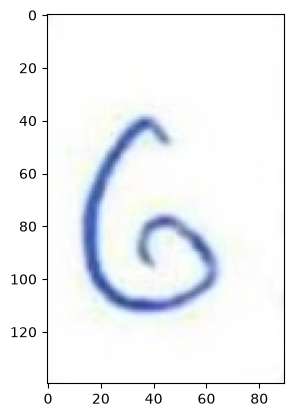

In [6]:
transforms_pred = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

model, class_names = checkpoint.load_checkpoint(model_path="models/mnist_model_lenet5_trained_experiments.pth",
                                                model=LeNet5(num_classes=10),
                                                device=device)

pred, prob = engine.predict(
  model=model,
  image_path=image_path,
  transform=transforms_pred,
  device=device
)

print(f"Prediction: {class_names[pred]}")
print(f"Confidence: {prob:.2%}")
plt.imshow(image)